# **8. Transformer**

## **8.1. Librerias**

In [6]:
import os
import copy
import random
import optuna

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_rel, wilcoxon
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import acf, pacf
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import (
    Dataset,
    DataLoader
)

import geopandas as gpd
from libpysal.weights import Queen
import sys
import time


## **8.2. Configuración Reproducibilidad**

In [7]:
SEEDS = [42, 123, 2024]

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("DEVICE:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("Python:", sys.version)
print("Torch:", torch.__version__)
print("Numpy:", np.__version__)
print("Pandas:", pd.__version__)


DEVICE: cuda
GPU: NVIDIA GeForce RTX 5050 Laptop GPU
Python: 3.10.20 (main, Mar  3 2026, 09:24:47) [GCC 13.3.0]
Torch: 2.11.0+cu130
Numpy: 2.2.6
Pandas: 2.3.3


El entorno de ejecución utiliza PyTorch 2.11 con soporte CUDA 13.0 y una GPU NVIDIA GeForce RTX 5050 Laptop, lo que permite acelerar significativamente el entrenamiento de modelos de deep learning. Además, la configuración de semillas múltiples y versiones recientes de librerías como NumPy y Pandas favorece la reproducibilidad y estabilidad experimental.

In [8]:
def set_seed(seed=42):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    torch.use_deterministic_algorithms(True)
    os.environ["PYTHONHASHSEED"] = str(seed)

    print(f"Seed fijada: {seed}")


def seed_worker(worker_id):

    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


g = torch.Generator()

Este código implementa una estrategia exhaustiva de **reproducibilidad en experimentos con PyTorch**, fijando semillas en `random`, `numpy` y `torch`, además de desactivar optimizaciones no deterministas de CUDA (como `cudnn.benchmark`) para garantizar resultados consistentes entre ejecuciones. Asimismo, se controla la aleatoriedad en los *data loaders* mediante `seed_worker` y un generador de PyTorch, asegurando coherencia en el muestreo paralelo de datos.

## **8.3. Carga de Datos & Preprocesamiento**

### **8.3.1. Carga de Datos**

In [9]:
df = pd.read_csv("/home/guirlessa/Dl_Proyecto_Dengue/Bases_Datos/df_full.csv")
df.head()

,departamento,fecha_inicio,ano,semana,casos,casos_mujeres,casos_hombres,casos_rural,casos_urbano,(0_5],...,precip_lag_12,precip_lag_20,temp_c,temp_lag_1,temp_lag_2,temp_lag_3,temp_lag_4,temp_lag_8,temp_lag_12,temp_lag_20
0,Amazonas,2012-01-02,2012,1,0.0,0,0,0,0,0,...,50.983546,39.108242,24.848668,24.890654,24.334752,24.545618,25.345678,25.278160,25.874930,24.364443
1,Amazonas,2012-01-09,2012,2,0.0,0,0,0,0,0,...,61.818291,62.830250,24.729721,24.848668,24.890654,24.334752,24.545618,25.084141,25.495665,24.971798
2,Amazonas,2012-01-16,2012,3,0.0,0,0,0,0,0,...,24.950393,42.988018,24.638674,24.729721,24.848668,24.890654,24.334752,25.751070,25.760539,25.304947
3,Amazonas,2012-01-23,2012,4,0.0,0,0,0,0,0,...,88.169343,56.572467,25.164008,24.638674,24.729721,24.848668,24.890654,25.284157,25.842089,25.166142
4,Amazonas,2012-01-30,2012,5,0.0,0,0,0,0,0,...,56.271440,74.893047,24.604644,25.164008,24.638674,24.729721,24.848668,25.345678,25.278160,25.312395


In [10]:
print("El dataframe tiene {0} filas y {1} columnas.".format(df.shape[0], df.shape[1]))

El dataframe tiene 21664 filas y 54 columnas.


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21664 entries, 0 to 21663
Data columns (total 54 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   departamento        21664 non-null  object 
 1   fecha_inicio        21664 non-null  object 
 2   ano                 21664 non-null  int64  
 3   semana              21664 non-null  int64  
 4   casos               21664 non-null  float64
 5   casos_mujeres       21664 non-null  int64  
 6   casos_hombres       21664 non-null  int64  
 7   casos_rural         21664 non-null  int64  
 8   casos_urbano        21664 non-null  int64  
 9   (0_5]               21664 non-null  int64  
 10  (5_13]              21664 non-null  int64  
 11  (13_26]             21664 non-null  int64  
 12  (26_60]             21664 non-null  int64  
 13  60_mas              21664 non-null  int64  
 14  casos_Contributivo  21664 non-null  int64  
 15  casos_No_asegurado  21664 non-null  int64  
 16  caso

Se observa que la variable `fecha_inicio` está tipificada como `object`, cuando en realidad debería corresponder al tipo `datetime`. Por ello, se procederá a realizar la conversión adecuada para garantizar un manejo correcto de fechas en las etapas posteriores de modelado.

In [12]:
df["fecha_inicio"] = pd.to_datetime(df["fecha_inicio"])

También se procede a organizar los registros del DataFrame según el departamento y la fecha de inicio, con el objetivo de asegurar una estructura temporal coherente que facilite el análisis y el posterior proceso de modelado.

In [13]:
df = df.sort_values(
    ["departamento", "fecha_inicio"]
).reset_index(drop=True)

### **8.3.2. Feature Enginering**

Con el fin de incorporar la estacionalidad anual de la enfermedad, se construyeron las variables cíclicas week_sin y week_cos a partir de la semana epidemiológica normalizada. Esta transformación permite representar la naturaleza periódica del calendario, preservando la continuidad entre el final y el inicio de cada año, y facilitando que los modelos capturen patrones estacionales recurrentes asociados a la transmisión del dengue.

In [14]:
weeks_per_year = df.groupby("ano")["semana"].transform("max")

df["week_norm"] = df["semana"] / weeks_per_year

df["week_sin"] = np.sin(2 * np.pi * df["week_norm"])

df["week_cos"] = np.cos(2 * np.pi * df["week_norm"])

Este conjunto de `FEATURES` define el espacio de variables utilizado para el modelado, combinando información temporal, climática y sociodemográfica. En particular, se incorporan múltiples **rezagos (lags)** de la incidencia y variables meteorológicas (temperatura, humedad y precipitación) para capturar dependencias temporales y efectos retardados, junto con variables estructurales como población y proporción rural. Adicionalmente, las componentes cíclicas `week_sin` y `week_cos` permiten modelar la estacionalidad semanal de forma continua, evitando discontinuidades propias de una codificación directa del tiempo.

In [15]:
FEATURES = [

    "inc_lag_1",
    "inc_lag_2",
    "inc_lag_3",
    "inc_lag_4",
    "inc_lag_8",
    "inc_lag_12",
    "inc_lag_20",

    "temp_lag_1",
    "temp_lag_2",
    "temp_lag_4",
    "temp_lag_8",
    "temp_lag_12",
    "temp_lag_20",

    "humedad_lag_1",
    "humedad_lag_2",
    "humedad_lag_4",
    "humedad_lag_8",
    "humedad_lag_12",
    "humedad_lag_20",

    "precip_lag_1",
    "precip_lag_2",
    "precip_lag_4",
    "precip_lag_8",
    "precip_lag_12",
    "precip_lag_20",

    "poblacion",
    "prop_rural",

    "week_sin",
    "week_cos"
]

Asimismo, durante el análisis exploratorio de datos se observó que la variable de incidencia presentaba una distribución fuertemente asimétrica hacia la derecha, caracterizada por la presencia de valores extremos asociados a periodos epidémicos. Debido a ello, se consideró necesario aplicar una transformación logarítmica con el objetivo de reducir la asimetría, estabilizar la varianza y facilitar que los modelos capturen de manera más adecuada la estructura temporal y los patrones subyacentes de la incidencia del dengue.

In [16]:
df["incidencia_log"] = np.log1p(df["incidencia"])

TARGET = "incidencia_log"

Con el fin de evaluar el efecto de la transformación logarítmica, se compararon las distribuciones de la incidencia antes y después del preprocesamiento. La distribución original presentaba una marcada asimetría positiva y una alta concentración de valores extremos asociados a periodos epidémicos. Tras aplicar la transformación logarítmica (log1p), se observó una reducción significativa del sesgo y una distribución más equilibrada, lo que contribuye a estabilizar la varianza y facilita la identificación de patrones temporales por parte de los modelos predictivos.

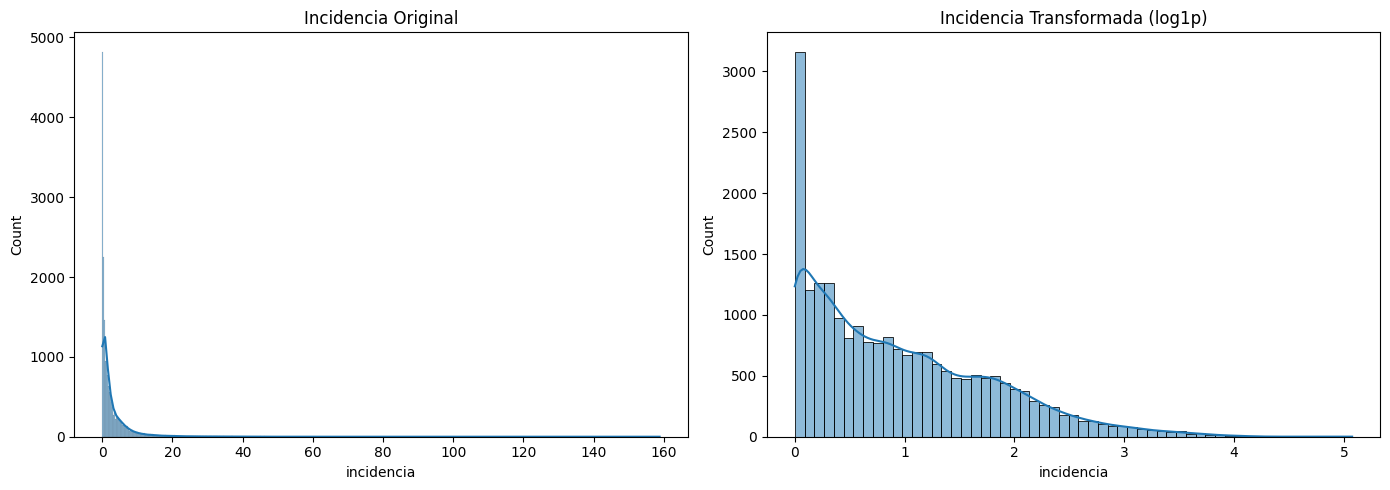

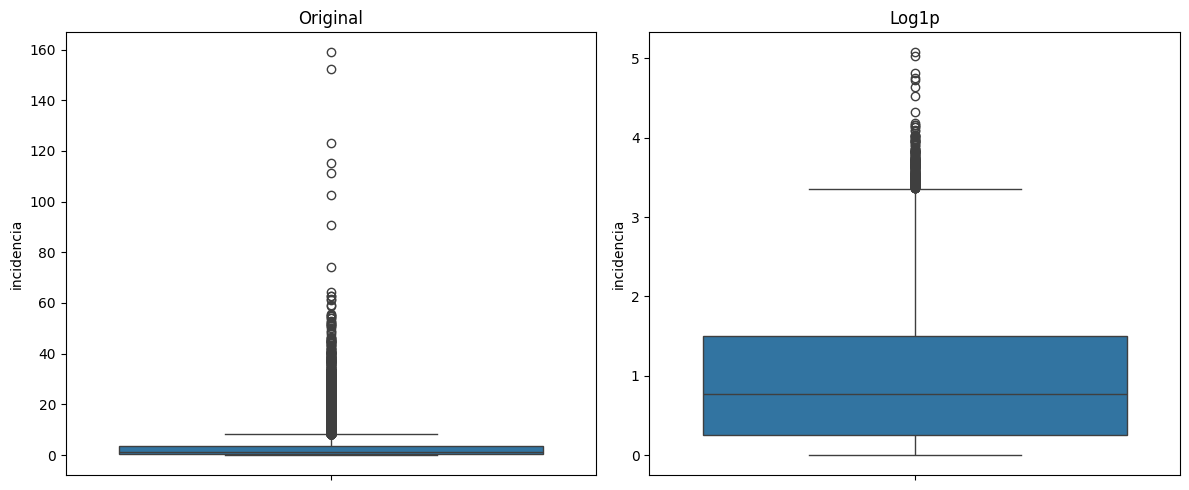

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    df["incidencia"],
    kde=True,
    ax=axes[0]
)
axes[0].set_title("Incidencia Original")

sns.histplot(
    np.log1p(df["incidencia"]),
    kde=True,
    ax=axes[1]
)
axes[1].set_title("Incidencia Transformada (log1p)")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(y=df["incidencia"], ax=axes[0])
axes[0].set_title("Original")

sns.boxplot(y=np.log1p(df["incidencia"]), ax=axes[1])
axes[1].set_title("Log1p")

plt.tight_layout()
plt.show()

### **8.3.3. Grafo Espacial**

In [ ]:
departments = sorted(df["departamento"].unique())

dept_to_idx = {d: i for i, d in enumerate(departments)}

idx_to_dept = {i: d for d, i in dept_to_idx.items()}

NUM_NODES = len(departments)

gdf = gpd.read_file(
    "/home/guirlessa/Dl_Proyecto_Dengue/Covariables/MGN_ADM_DPTO_POLITICO/MGN_ADM_DPTO_POLITICO_limpio.shp"
)

gdf = gdf.set_index("dpto_cnmbr").loc[departments].reset_index()


def build_queen_adj(gdf, departments):

    w   = Queen.from_dataframe(gdf)
    adj = np.zeros(
        (len(departments), len(departments)),
        dtype=np.float32
    )

    for i, neighbors in w.neighbors.items():
        for j in neighbors:
            adj[i, j] = 1.0

    np.fill_diagonal(adj, 1.0)

    return adj


def normalize_adj(adj):

    D = np.diag(np.power(adj.sum(axis=1), -0.5))

    return (D @ adj @ D).astype(np.float32)


adj_raw        = build_queen_adj(gdf, departments)
adj_normalized = normalize_adj(adj_raw)

adj_matrix = torch.tensor(
    adj_normalized,
    dtype=torch.float32
).to(DEVICE)

/tmp/ipykernel_162470/1012815684.py:26: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w   = Queen.from_dataframe(gdf)


### **8.3.4. Normalización de los Datos**

Se plantea la función scale_data con el fin de aplicar una normalización robusta (RobustScaler) a los datos de entrenamiento y validación, para así preservar la estructura original de series temporales multivariadas. Para ello, primero reestructura los tensores a dos dimensiones para ajustar el escalador únicamente sobre el conjunto de entrenamiento, evitando *data leakage*, y luego transforma ambos conjuntos antes de devolverlos a su forma original.

In [18]:
def scale_data(X_train, X_val):

    scaler = RobustScaler()

    _, _, _, n_features = X_train.shape

    X_train_2d = X_train.reshape(-1, n_features)

    scaler.fit(X_train_2d)

    X_train_scaled = scaler.transform(X_train_2d).reshape(X_train.shape)

    X_val_scaled = scaler.transform(
        X_val.reshape(-1, n_features)
    ).reshape(X_val.shape)

    return X_train_scaled, X_val_scaled, scaler

## **8.4. Esquema de validación temporal**

Se implementa un esquema de validación cruzada temporal anidada (nested time series cross-validation), en el cual los datos se dividen respetando estrictamente el orden cronológico para evitar *data leakage*. En el nivel externo, se definen particiones de entrenamiento y prueba por año (2022–2024), simulando un escenario real de predicción futura; mientras que en el nivel interno, el conjunto de entrenamiento se subdivide nuevamente en conjuntos de entrenamiento y validación (2019–2021) para ajuste de hiperparámetros y selección de modelos. Este enfoque garantiza una evaluación más robusta y realista al emular la dinámica de predicción en series temporales.

In [19]:
def create_outer_folds(df, date_col="fecha_inicio"):

    folds       = []
    outer_years = [2022, 2023, 2024]

    for test_year in outer_years:

        train_df = df[df[date_col].dt.year <  test_year].copy()
        test_df  = df[df[date_col].dt.year == test_year].copy()

        folds.append({
            "test_year": test_year,
            "train_df":  train_df,
            "test_df":   test_df
        })

    return folds


outer_folds = create_outer_folds(df)

def create_inner_folds(train_df, val_years=[2019, 2020, 2021]):

    inner_folds = []

    for val_year in val_years:

        inner_train = train_df[
            train_df["fecha_inicio"].dt.year < val_year
        ].copy()

        inner_val = train_df[
            train_df["fecha_inicio"].dt.year == val_year
        ].copy()

        inner_folds.append({
            "val_year":    val_year,
            "inner_train": inner_train,
            "inner_val":   inner_val
        })

    return inner_folds

In [6]:
# ============================================================
# CREATE WINDOWS
# ============================================================

def create_windows(
    df,
    features,
    target,
    window_size=12,
    horizon=4
):

    pivot_features = []

    for feat in features:

        pivot = df.pivot_table(
            index="fecha_inicio",
            columns="departamento",
            values=feat
        ).sort_index()

        pivot_features.append(pivot.values)

    X_all = np.stack(pivot_features, axis=-1)

    target_pivot = df.pivot_table(
        index="fecha_inicio",
        columns="departamento",
        values=target
    ).sort_index()

    y_all = target_pivot.values
    dates = target_pivot.index.values

    X          = []
    y          = []
    base_dates = []

    total_steps = len(dates)

    for i in range(total_steps - window_size - horizon + 1):

        X.append(X_all[i : i + window_size])

        y.append(y_all[i + window_size : i + window_size + horizon])

        base_dates.append(dates[i + window_size - 1])

    X          = np.array(X, dtype=np.float32)
    y          = np.array(y, dtype=np.float32)
    base_dates = np.array(base_dates)

    return X, y, base_dates

## **8.5. Ventanas de Tiempo**

Esta función implementa la construcción del conjunto de datos supervisado para modelado espaciotemporal, mediante la transformación de datos tabulares en tensores estructurados compatibles con arquitecturas de aprendizaje profundo. En primer lugar, reorganiza las variables explicativas y la variable objetivo a través de tablas pivote indexadas por fecha y departamento, asegurando consistencia en la representación espacial. Posteriormente, se unifican las variables en un tensor multivariado y se genera una estructura de secuencias mediante una estrategia de ventanas deslizantes (sliding window), en la que se define explícitamente un historial de observación (window_size) y un horizonte de predicción (horizon). Finalmente, se preserva información auxiliar como las fechas de referencia y el orden de los departamentos, lo cual es fundamental para mantener la coherencia temporal y espacial del conjunto de datos.

In [20]:
def create_windows(
    df,
    features,
    target,
    window_size=12,
    horizon=4
):

    pivot_features = []

    for feat in features:

        pivot = df.pivot_table(
            index="fecha_inicio",
            columns="departamento",
            values=feat
        ).sort_index()

        pivot_features.append(pivot.values)

    X_all = np.stack(pivot_features, axis=-1)

    target_pivot = df.pivot_table(
        index="fecha_inicio",
        columns="departamento",
        values=target
    ).sort_index()

    y_all = target_pivot.values
    dates = target_pivot.index.values

    X          = []
    y          = []
    base_dates = []

    total_steps = len(dates)

    for i in range(total_steps - window_size - horizon + 1):

        X.append(X_all[i : i + window_size])

        y.append(y_all[i + window_size : i + window_size + horizon])

        base_dates.append(dates[i + window_size - 1])

    X          = np.array(X, dtype=np.float32)
    y          = np.array(y, dtype=np.float32)
    base_dates = np.array(base_dates)

    return X, y, base_dates

## **8.6. Funciones para el Modelado**

La clase EarlyStopping introduce un mecanismo de regularización basado en la detención anticipada del entrenamiento cuando la pérdida de validación deja de mejorar durante un número determinado de épocas (patience), lo cual ayuda a prevenir sobreajuste.

In [21]:
class EarlyStopping:

    def __init__(self, patience=20):

        self.patience  = patience
        self.best_loss = np.inf
        self.counter   = 0
        self.stop      = False

    def step(self, val_loss):

        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter   = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True


Por otro lado, train_one_epoch y validate_one_epoch definen los ciclos estándar de entrenamiento y evaluación por época, respectivamente: la primera realiza la optimización del modelo mediante retropropagación del error, actualización de parámetros y recorte de gradientes para estabilizar el aprendizaje, mientras que la segunda evalúa el desempeño del modelo en modo inferencia sin actualización de pesos, permitiendo monitorear su generalización.

In [22]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):

    model.train()
    total_loss = 0

    for X_batch, y_batch in dataloader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        pred = model(X_batch)

        loss = criterion(pred, y_batch)

        loss.backward()

        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)

In [23]:
def validate_one_epoch(model, dataloader, criterion, device):

    model.eval()
    total_loss = 0

    with torch.no_grad():

        for X_batch, y_batch in dataloader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            pred = model(X_batch)

            loss = criterion(pred, y_batch)

            total_loss += loss.item()

    return total_loss / len(dataloader)

## **8.7. Arquitectura**

In [24]:
class Dataset(Dataset):

    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


In [25]:
class SpatioTemporalTransformer(nn.Module):

    def __init__(
        self,
        num_nodes,
        in_channels,
        hidden_size=128,
        num_layers=2,
        nhead=4,
        horizon=4,
        dropout=0.1
    ):
        super().__init__()

        self.num_nodes = num_nodes
        self.horizon = horizon
        self.hidden_size = hidden_size

        self.input_proj = nn.Linear(in_channels, hidden_size)

        self.time_emb = nn.Parameter(torch.randn(1, 50, hidden_size))  # max T
        self.node_emb = nn.Parameter(torch.randn(1, num_nodes, hidden_size))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_size,
            nhead=nhead,
            dim_feedforward=hidden_size * 4,
            dropout=dropout,
            batch_first=True
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.head = nn.Linear(hidden_size, horizon)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, adj=None):

        B, T, N, F = x.shape

        x = self.input_proj(x)  

        x = x.reshape(B, T * N, self.hidden_size)

        device = x.device
        seq_len = x.size(1)

        position = torch.arange(seq_len, device=device).unsqueeze(0).unsqueeze(-1)
        div_term = torch.exp(
            torch.arange(0, self.hidden_size, 2, device=device)
            * (-torch.log(torch.tensor(10000.0, device=device)) / self.hidden_size)
        )

        pe = torch.zeros(seq_len, self.hidden_size, device=device)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        x = x + pe.unsqueeze(0)

        x = self.encoder(x)

        x = x.reshape(B, T, N, self.hidden_size)

        x = x[:, -1, :, :]  

        out = self.head(x)  

        return out.permute(0, 2, 1)  

## **8.8. Optimización de Hiperparametros**

Inicializamos el entorno experimental del pipeline de optimización y evaluación del modelo,  definiendo estructuras globales para almacenar resultados de múltiples etapas del experimento (tuning, validación cruzada, entrenamiento y evaluación final).

In [26]:
ALL_OPTUNA_TRIALS = []
ALL_OPTUNA_FOLDS = []
ALL_RESIDUALS = []
ALL_INFERENCE_TIME = []
ALL_BEST_PARAMS = []
ALL_RESULTS     = []
ALL_PREDICTIONS = []
ALL_LOSSES      = []

TUNING_DF = df[df["fecha_inicio"].dt.year < 2022].copy()

INNER_FOLDS_TUNING = create_inner_folds(
    TUNING_DF,
    val_years=[2019, 2020, 2021]
)

Ahora, definimos objetivo de optimización para el ajuste de hiperparámetros mediante Optuna, evaluando distintas configuraciones del modelo Transformer. Para cada *trial*, se muestrean hiperparámetros como tamaño de ventana, tasa de aprendizaje, tamaño de lote, número de capas, unidades ocultas, tamaño de kernel y *dropout*, y se evalúan mediante validación cruzada en los *inner folds*. En cada partición se entrena el modelo, se aplica *early stopping* y se calcula el RMSE sobre el conjunto de validación, retornando finalmente el error promedio como métrica a minimizar.

In [ ]:
def objective(trial):
    
    window_size = trial.suggest_categorical(
        "window_size", [4, 8, 12, 16]
    )

    learning_rate = trial.suggest_float(
        "learning_rate", 1e-4, 1e-2, log=True
    )

    batch_size = trial.suggest_categorical(
        "batch_size", [16, 32]
    )

    hidden_size = trial.suggest_categorical(
        "hidden_size", [32, 64, 128]
    )

    num_layers = trial.suggest_int(
        "num_layers", 1, 3
    )

    kernel_size = trial.suggest_categorical(
        "kernel_size", [3, 5, 7]
    )

    dropout = trial.suggest_float(
        "dropout", 0.0, 0.4, step=0.1
    )


    rmse_folds = []
    fold_errors = []


    for fold_id, fold in enumerate(INNER_FOLDS_TUNING):


        X_train, y_train, _ = create_windows(
            fold["inner_train"],
            FEATURES,
            TARGET,
            window_size,
            4
        )

        X_val, y_val, _ = create_windows(
            fold["inner_val"],
            FEATURES,
            TARGET,
            window_size,
            4
        )

        
        X_train_scaled, X_val_scaled, _ = scale_data(X_train, X_val)

        train_dataset = Dataset(X_train_scaled, y_train)
        val_dataset   = Dataset(X_val_scaled, y_val)

        g.manual_seed(seed)

        train_loader = DataLoader(
            train_dataset,
            batch_size=batch_size,
            shuffle=False,
            worker_init_fn=seed_worker,
            generator=g
        )

        val_loader = DataLoader(
            val_dataset,
            batch_size=batch_size,
            shuffle=False
        )

        model = SpatioTemporalTransformer(
            num_nodes=NUM_NODES,
            in_channels=len(FEATURES),
            hidden_size=hidden_size,
            num_layers=num_layers,
            nhead=4,
            horizon=4,
            dropout=dropout
        ).to(DEVICE)

        criterion = nn.MSELoss()

        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=learning_rate
        )

        early_stopping = EarlyStopping(patience=10)

        for epoch in range(50):

            train_one_epoch(
                model, train_loader, criterion, optimizer, DEVICE
            )

            val_loss = validate_one_epoch(
                model, val_loader, criterion, DEVICE
            )

            early_stopping.step(val_loss)

            if early_stopping.stop:
                break

    
        model.eval()

        preds = []
        trues = []

        with torch.no_grad():

            for X_batch, y_batch in val_loader:

                pred = model(X_batch.to(DEVICE), adj_matrix)

                preds.append(pred.cpu().numpy())
                trues.append(y_batch.numpy())

        preds = np.concatenate(preds)
        trues = np.concatenate(trues)

    
        errors = trues - preds

        rmse = np.sqrt(
            mean_squared_error(trues.flatten(), preds.flatten())
        )

        rmse_folds.append(rmse)

        fold_errors.append({
            "trial": trial.number,
            "seed": seed,
            "fold": fold_id,
            "rmse": rmse,
            "error_mean": float(np.mean(errors)),
            "error_std": float(np.std(errors))
        })

    rmse_mean = float(np.mean(rmse_folds))
    rmse_std  = float(np.std(rmse_folds))

    ALL_OPTUNA_TRIALS.append({
        "trial": trial.number,
        "seed": seed,
        "window_size": window_size,
        "learning_rate": learning_rate,
        "batch_size": batch_size,
        "hidden_size": hidden_size,
        "num_layers": num_layers,
        "kernel_size": kernel_size,
        "dropout": dropout,
        "rmse_mean": rmse_mean,
        "rmse_std": rmse_std
    })

    ALL_OPTUNA_FOLDS.extend(fold_errors)

    trial.set_user_attr("rmse_folds", rmse_folds)
    trial.set_user_attr("rmse_std", rmse_std)

    return rmse_mean

## **8.9. Pipeline Train, Validation & Test**

In [ ]:

for seed in SEEDS:

    print("\n")
    print("="*100)
    print(f"SEED {seed}")
    print("="*100)

    set_seed(seed)

    sampler = optuna.samplers.TPESampler(seed=seed)

    study = optuna.create_study(
        direction="minimize",
        sampler=sampler
    )

    study.optimize(objective, n_trials=30)

    best_params = study.best_trial.params

    print(f"\nMejores hiperparámetros para seed {seed}:")
    print(best_params)

    pd.DataFrame([{"seed": seed, **best_params}]).to_csv(
        f"/home/guirlessa/Dl_Proyecto_Dengue/Modelos/Transformer/transformer_best_params_seed_{seed}.csv",
        index=False
    )

    ALL_BEST_PARAMS.append({"seed": seed, **best_params})

    for outer_idx, outer_fold in enumerate(outer_folds):

        print("\n")
        print("="*100)
        print(f"OUTER FOLD {outer_idx+1} | Test year: {outer_fold['test_year']}")
        print("="*100)

        outer_train_df = outer_fold["train_df"]
        final_test_df  = outer_fold["test_df"]

        window_size   = best_params["window_size"]
        hidden_size   = best_params["hidden_size"]
        num_layers    = best_params["num_layers"]
        kernel_size   = best_params["kernel_size"]
        dropout       = best_params["dropout"]
        learning_rate = best_params["learning_rate"]
        batch_size    = best_params["batch_size"]

        val_year = outer_train_df["fecha_inicio"].dt.year.max()

        final_train_df = outer_train_df[
            outer_train_df["fecha_inicio"].dt.year < val_year
        ]

        final_val_df = outer_train_df[
            outer_train_df["fecha_inicio"].dt.year == val_year
        ]

        X_train, y_train, train_dates = create_windows(
            final_train_df, FEATURES, TARGET, window_size, 4
        )

        X_val, y_val, val_dates = create_windows(
            final_val_df, FEATURES, TARGET, window_size, 4
        )

        X_test, y_test, test_dates = create_windows(
            final_test_df, FEATURES, TARGET, window_size, 4
        )

        X_train_scaled, X_val_scaled, scaler = scale_data(X_train, X_val)

        X_test_scaled = scaler.transform(
            X_test.reshape(-1, X_test.shape[-1])
        ).reshape(X_test.shape)

        train_dataset = Dataset(X_train_scaled, y_train)
        val_dataset   = Dataset(X_val_scaled,   y_val)
        test_dataset  = Dataset(X_test_scaled,  y_test)

        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
        val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
        test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

        model = SpatioTemporalTransformer(
            num_nodes=NUM_NODES,
            in_channels=len(FEATURES),
            hidden_size=hidden_size,
            num_layers=num_layers,
            nhead=4,
            horizon=4,
            dropout=dropout
        ).to(DEVICE)

        criterion = nn.MSELoss()

        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=learning_rate
        )

        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=0.5, patience=10
        )

        early_stopping = EarlyStopping(patience=20)

        best_model = None
        best_loss = np.inf

        total_train_time = 0.0

        for epoch in range(300):

            start_epoch = time.time()

            train_loss = train_one_epoch(
                model, train_loader, criterion, optimizer, DEVICE
            )

            val_loss = validate_one_epoch(
                model, val_loader, criterion, DEVICE
            )

            scheduler.step(val_loss)

            epoch_time = time.time() - start_epoch
            total_train_time += epoch_time

            print(
                f"Epoch {epoch+1}"
                f" | Train {train_loss:.4f}"
                f" | Val {val_loss:.4f}"
                f" | Time {epoch_time:.2f}s"
            )

            ALL_LOSSES.append({
                "seed": seed,
                "outer_fold": outer_idx + 1,
                "test_year": outer_fold["test_year"],
                "epoch": epoch + 1,
                "train_loss": train_loss,
                "val_loss": val_loss,
                "epoch_time": epoch_time
            })

            if val_loss < best_loss:
                best_loss = val_loss
                best_model = copy.deepcopy(model)

            early_stopping.step(val_loss)

            if early_stopping.stop:
                break

        model = best_model

        torch.save(
            model.state_dict(),
            f"/home/guirlessa/Dl_Proyecto_Dengue/Modelos/Transformer/"
            f"transformer_seed_{seed}_outer_fold_{outer_idx+1}.pt"
        )

        model.eval()

        start_inference = time.time()

        predictions = []
        targets = []

        with torch.no_grad():
            for X_batch, y_batch in test_loader:

                X_batch = X_batch.to(DEVICE)

                pred = model(X_batch)

                predictions.append(pred.cpu().numpy())
                targets.append(y_batch.numpy())

        inference_time = time.time() - start_inference

        predictions = np.concatenate(predictions)
        targets     = np.concatenate(targets)

        mse  = mean_squared_error(targets.flatten(), predictions.flatten())
        rmse = np.sqrt(mse)
        mae  = mean_absolute_error(targets.flatten(), predictions.flatten())
        r2   = r2_score(targets.flatten(), predictions.flatten())

        ALL_RESULTS.append({
            "seed": seed,
            "outer_fold": outer_idx + 1,
            "test_year": outer_fold["test_year"],
            "mse": mse,
            "rmse": rmse,
            "mae": mae,
            "r2": r2,
            "train_time": total_train_time,
            "inference_time": inference_time
        })

        ALL_INFERENCE_TIME.append({
            "seed": seed,
            "outer_fold": outer_idx + 1,
            "test_year": outer_fold["test_year"],
            "inference_time": inference_time,
            "train_time": total_train_time
        })

        rows = []

        for i in range(len(predictions)):
            for h in range(4):
                for node in range(NUM_NODES):

                    y_true = targets[i, h, node]
                    y_pred = predictions[i, h, node]

                    residual = y_true - y_pred

                    rows.append({
                        "seed": seed,
                        "outer_fold": outer_idx + 1,
                        "test_year": outer_fold["test_year"],
                        "departamento": idx_to_dept[node],
                        "fecha_base": test_dates[i],
                        "horizonte": h + 1,

                        "y_true_log": y_true,
                        "y_pred_log": y_pred,

                        "y_true_real": np.expm1(y_true),
                        "y_pred_real": np.expm1(y_pred),

                        "residual": residual,
                        "abs_error": abs(residual),
                        "sq_error": residual ** 2
                    })

                    ALL_RESIDUALS.append({
                        "seed": seed,
                        "outer_fold": outer_idx + 1,
                        "test_year": outer_fold["test_year"],
                        "departamento": idx_to_dept[node],
                        "fecha_base": test_dates[i],
                        "horizonte": h + 1,
                        "residual": residual
                    })

        ALL_PREDICTIONS.append(pd.DataFrame(rows))

[I 2026-06-01 13:56:27,618] A new study created in memory with name: no-name-5cb32175-1498-45b0-9b25-c4710b10fc02




SEED 42
Seed fijada: 42


[I 2026-06-01 13:56:50,156] Trial 0 finished with value: 0.44550756011259773 and parameters: {'window_size': 8, 'learning_rate': 0.0002051338263087451, 'batch_size': 16, 'hidden_size': 32, 'num_layers': 1, 'kernel_size': 3, 'dropout': 0.0}. Best is trial 0 with value: 0.44550756011259773.
[I 2026-06-01 13:57:21,993] Trial 1 finished with value: 0.4803451877046448 and parameters: {'window_size': 12, 'learning_rate': 0.0003823475224675188, 'batch_size': 16, 'hidden_size': 128, 'num_layers': 3, 'kernel_size': 7, 'dropout': 0.0}. Best is trial 0 with value: 0.44550756011259773.
[I 2026-06-01 13:57:38,264] Trial 2 finished with value: 0.42499712527698547 and parameters: {'window_size': 16, 'learning_rate': 0.00853618986286683, 'batch_size': 16, 'hidden_size': 64, 'num_layers': 1, 'kernel_size': 7, 'dropout': 0.1}. Best is trial 2 with value: 0.42499712527698547.
[I 2026-06-01 13:58:10,741] Trial 3 finished with value: 0.4359181112384838 and parameters: {'window_size': 4, 'learning_rate': 0.


Mejores hiperparámetros para seed 42:
{'window_size': 16, 'learning_rate': 0.0006687902666583148, 'batch_size': 32, 'hidden_size': 128, 'num_layers': 2, 'kernel_size': 3, 'dropout': 0.30000000000000004}


OUTER FOLD 1 | Test year: 2022
Epoch 1 | Train 0.8387 | Val 0.5625 | Time 0.51s
Epoch 2 | Train 0.3893 | Val 0.2842 | Time 0.48s
Epoch 3 | Train 0.2793 | Val 0.1403 | Time 0.48s
Epoch 4 | Train 0.1921 | Val 0.1309 | Time 0.48s
Epoch 5 | Train 0.1648 | Val 0.1126 | Time 0.48s
Epoch 6 | Train 0.1559 | Val 0.1434 | Time 0.49s
Epoch 7 | Train 0.1517 | Val 0.1284 | Time 0.49s
Epoch 8 | Train 0.1700 | Val 0.1709 | Time 0.48s
Epoch 9 | Train 0.1511 | Val 0.1493 | Time 0.48s
Epoch 10 | Train 0.1558 | Val 0.1182 | Time 0.48s
Epoch 11 | Train 0.1635 | Val 0.1236 | Time 0.49s
Epoch 12 | Train 0.1635 | Val 0.1154 | Time 0.48s
Epoch 13 | Train 0.1529 | Val 0.1297 | Time 0.48s
Epoch 14 | Train 0.1559 | Val 0.1192 | Time 0.48s
Epoch 15 | Train 0.1434 | Val 0.1305 | Time 0.48s
Epoch 16 | Train 0.143

[I 2026-06-01 14:11:35,706] A new study created in memory with name: no-name-4f75804d-448d-4c84-b8e4-a0f0f556354e


...


Mejores hiperparámetros para seed 123:
{'window_size': 16, 'learning_rate': 0.0012460261167843497, 'batch_size': 32, 'hidden_size': 32, 'num_layers': 3, 'kernel_size': 3, 'dropout': 0.4}


OUTER FOLD 1 | Test year: 2022
Epoch 1 | Train 0.6839 | Val 0.3498 | Time 0.49s
Epoch 2 | Train 0.3873 | Val 0.2504 | Time 0.48s
Epoch 3 | Train 0.2903 | Val 0.1763 | Time 0.49s
Epoch 4 | Train 0.2400 | Val 0.1565 | Time 0.49s
Epoch 5 | Train 0.2129 | Val 0.1406 | Time 0.49s
Epoch 6 | Train 0.1903 | Val 0.1290 | Time 0.49s
Epoch 7 | Train 0.1796 | Val 0.1267 | Time 0.49s
Epoch 8 | Train 0.1703 | Val 0.1205 | Time 0.49s
Epoch 9 | Train 0.1599 | Val 0.1122 | Time 0.48s
Epoch 10 | Train 0.1560 | Val 0.1127 | Time 0.48s
Epoch 11 | Train 0.1527 | Val 0.1127 | Time 0.49s
Epoch 12 | Train 0.1492 | Val 0.1093 | Time 0.48s
Epoch 13 | Train 0.1440 | Val 0.1058 | Time 0.48s
Epoch 14 | Train 0.1422 | Val 0.1069 | Time 0.48s
Epoch 15 | Train 0.1398 | Val 0.1064 | Time 0.48s
Epoch 16 | Train 0.1370 | Val 0.1105 |

[I 2026-06-01 14:30:43,088] A new study created in memory with name: no-name-b54ef6bb-d108-408e-9d5a-20d214f65f2d


Epoch 59 | Train 0.1112 | Val 0.1411 | Time 0.59s


SEED 2024
Seed fijada: 2024


[I 2026-06-01 14:30:57,359] Trial 0 finished with value: 0.41519827047611363 and parameters: {'window_size': 8, 'learning_rate': 0.00025706201341357387, 'batch_size': 32, 'hidden_size': 32, 'num_layers': 1, 'kernel_size': 7, 'dropout': 0.30000000000000004}. Best is trial 0 with value: 0.41519827047611363.
[I 2026-06-01 14:31:50,059] Trial 1 finished with value: 0.4848709016117665 and parameters: {'window_size': 16, 'learning_rate': 0.0029616462592929973, 'batch_size': 16, 'hidden_size': 32, 'num_layers': 3, 'kernel_size': 3, 'dropout': 0.1}. Best is trial 0 with value: 0.41519827047611363.
[I 2026-06-01 14:32:05,464] Trial 2 finished with value: 0.4047139446079462 and parameters: {'window_size': 8, 'learning_rate': 0.005848943222502433, 'batch_size': 32, 'hidden_size': 32, 'num_layers': 2, 'kernel_size': 7, 'dropout': 0.4}. Best is trial 2 with value: 0.4047139446079462.
[I 2026-06-01 14:32:20,413] Trial 3 finished with value: 0.3813234880723723 and parameters: {'window_size': 12, 'lea


Mejores hiperparámetros para seed 2024:
{'window_size': 12, 'learning_rate': 0.0004310360420547543, 'batch_size': 32, 'hidden_size': 128, 'num_layers': 1, 'kernel_size': 5, 'dropout': 0.30000000000000004}


OUTER FOLD 1 | Test year: 2022
Epoch 1 | Train 0.6234 | Val 0.2585 | Time 0.21s
Epoch 2 | Train 0.2472 | Val 0.1437 | Time 0.19s
Epoch 3 | Train 0.1968 | Val 0.1382 | Time 0.19s
Epoch 4 | Train 0.1775 | Val 0.1256 | Time 0.19s
Epoch 5 | Train 0.1676 | Val 0.1155 | Time 0.18s
Epoch 6 | Train 0.1693 | Val 0.1245 | Time 0.18s
Epoch 7 | Train 0.1662 | Val 0.1182 | Time 0.19s
Epoch 8 | Train 0.1583 | Val 0.1165 | Time 0.19s
Epoch 9 | Train 0.1547 | Val 0.1201 | Time 0.19s
Epoch 10 | Train 0.1504 | Val 0.1193 | Time 0.19s
Epoch 11 | Train 0.1440 | Val 0.1107 | Time 0.19s
Epoch 12 | Train 0.1401 | Val 0.1064 | Time 0.19s
Epoch 13 | Train 0.1403 | Val 0.1080 | Time 0.19s
Epoch 14 | Train 0.1424 | Val 0.1128 | Time 0.19s
Epoch 15 | Train 0.1408 | Val 0.1100 | Time 0.19s
Epoch 16 | Train 0.1

In [ ]:
results_df        = pd.DataFrame(ALL_RESULTS)
predictions_df    = pd.concat(ALL_PREDICTIONS, axis=0)
losses_df         = pd.DataFrame(ALL_LOSSES)
best_params_df    = pd.DataFrame(ALL_BEST_PARAMS)

optuna_trials_df  = pd.DataFrame(ALL_OPTUNA_TRIALS)
optuna_folds_df   = pd.DataFrame(ALL_OPTUNA_FOLDS)

inference_df      = pd.DataFrame(ALL_INFERENCE_TIME)
residuals_df      = pd.DataFrame(ALL_RESIDUALS)

BASE_PATH = "/home/guirlessa/Dl_Proyecto_Dengue/Modelos/Transformer"

results_df.to_csv(f"{BASE_PATH}/transformer_results.csv", index=False)

predictions_df.to_csv(
    f"{BASE_PATH}/transformer_predictions.csv",
    index=False
)

losses_df.to_csv(
    f"{BASE_PATH}/transformer_training_history.csv",
    index=False
)

best_params_df.to_csv(
    f"{BASE_PATH}/transformer_best_params.csv",
    index=False
)

optuna_trials_df.to_csv(
    f"{BASE_PATH}/transformer_optuna_trials.csv",
    index=False
)

optuna_folds_df.to_csv(
    f"{BASE_PATH}/transformer_optuna_folds.csv",
    index=False
)

inference_df.to_csv(
    f"{BASE_PATH}/transformer_inference_time.csv",
    index=False
)

residuals_df.to_csv(
    f"{BASE_PATH}/transformer_residuals.csv",
    index=False
)

print("\n" + "="*100)
print("FINAL RESULTS")
print("="*100)

print(results_df.describe())


FINAL RESULTS
              seed  outer_fold    test_year       mse      rmse       mae  \
count     9.000000    9.000000     9.000000  9.000000  9.000000  9.000000   
mean    729.666667    2.000000  2023.000000  0.175852  0.412891  0.300788   
std     971.383421    0.866025     0.866025  0.069344  0.077749  0.078260   
min      42.000000    1.000000  2022.000000  0.114687  0.338655  0.229052   
25%      42.000000    1.000000  2022.000000  0.120696  0.347413  0.236658   
50%     123.000000    2.000000  2023.000000  0.154389  0.392923  0.284219   
75%    2024.000000    3.000000  2024.000000  0.216846  0.465667  0.357944   
max    2024.000000    3.000000  2024.000000  0.321800  0.567274  0.458342   

             r2  train_time  inference_time  
count  9.000000    9.000000        9.000000  
mean   0.730317   28.686147        0.008555  
std    0.096362   12.765854        0.002856  
min    0.522257   11.404794        0.004941  
25%    0.678071   20.494043        0.005706  
50%    0.745724

## **8.10. Evaluando Modelo**

In [2]:
MODEL_NAME = "Transformer"
BASE_PATH = "Modelos/Transformer"

results = pd.read_csv(f"{BASE_PATH}/transformer_results.csv")
preds = pd.read_csv(f"{BASE_PATH}/transformer_predictions.csv")
residuals = pd.read_csv(f"{BASE_PATH}/transformer_residuals.csv")
history = pd.read_csv(f"{BASE_PATH}/transformer_training_history.csv")

In [3]:
def compute_metrics(df, col_true='y_true_real', col_pred='y_pred_real', col_seed='seed'):
    metrics = []
    for seed in df[col_seed].unique():
        subset = df[df[col_seed] == seed]

        rmse = np.sqrt(mean_squared_error(subset[col_true], subset[col_pred]))
        mae = mean_absolute_error(subset[col_true], subset[col_pred])
        r2 = r2_score(subset[col_true], subset[col_pred])

        metrics.append({
            'seed': seed,
            'RMSE': rmse,
            'MAE': mae,
            'R2': r2
        })

    return pd.DataFrame(metrics)


metrics_real = compute_metrics(preds)

print(metrics_real)

metrics_real.to_csv(f"{BASE_PATH}/metrics_lstm.csv", index=False)

   seed      RMSE       MAE        R2
0    42  4.238087  2.222511  0.641611
1   123  4.221740  2.123134  0.644371
2  2024  3.703285  1.962430  0.759879


Los resultados del modelo Transformer muestran un desempeño sólido y consistente entre semillas. El RMSE oscila entre 3.70 y 4.24, con un promedio cercano a 4.05, mientras que el MAE se mantiene entre 1.96 y 2.22, lo que indica un nivel de error relativamente bajo y estable. En cuanto al R², los valores se sitúan entre 0.64 y 0.76, evidenciando una capacidad explicativa moderada-alta de la variabilidad de la serie, con un mejor ajuste en algunas ejecuciones. En conjunto, estos resultados sugieren que el Transformer logra capturar de manera efectiva las dependencias temporales del fenómeno, mostrando un desempeño superior a modelos previos más simples y una buena estabilidad en su comportamiento predictivo.


In [13]:
summary_real = metrics_real[['RMSE','MAE','R2']].agg(['mean','std'])

print("\nResumen Transformer:\n", summary_real)


Resumen Transformer:
           RMSE       MAE        R2
mean  4.054371  2.102692  0.681954
std   0.304159  0.131240  0.067499


El resumen global del modelo Transformer muestra un RMSE promedio de 4.05 y un MAE de 2.10, lo que indica un nivel de error relativamente bajo en las predicciones. El R² promedio de 0.68 refleja una capacidad explicativa moderada-alta, evidenciando que el modelo logra capturar una proporción importante de la variabilidad de la serie. La desviación estándar en las métricas es baja a moderada, lo que sugiere un desempeño razonablemente estable entre semillas, aunque con cierta variabilidad en la capacidad explicativa. En conjunto, estos resultados indican que el Transformer presenta un buen equilibrio entre precisión y generalización.


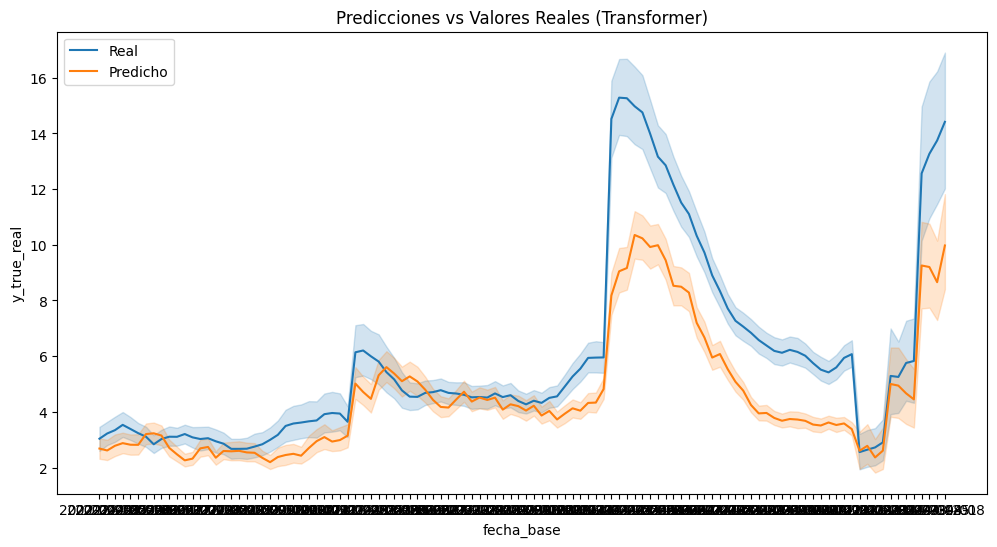

In [14]:
plt.figure(figsize=(12,6))
sns.lineplot(x='fecha_base', y='y_true_real', data=preds, label='Real')
sns.lineplot(x='fecha_base', y='y_pred_real', data=preds, label='Predicho')
plt.title("Predicciones vs Valores Reales (Transformer)")
plt.legend()
plt.show()

El gráfico de predicciones vs valores reales del modelo Transformer muestra que el modelo logra capturar adecuadamente la tendencia general de la serie temporal, especialmente en los cambios de dirección y en la evolución progresiva de los valores. Sin embargo, se observa una subestimación consistente de los picos de mayor magnitud, donde las predicciones tienden a ser más suaves y con menor amplitud que los valores observados. En conjunto, el Transformer evidencia una buena capacidad para seguir la dinámica temporal de la serie, pero con limitaciones en la representación de eventos extremos, lo que sugiere una pérdida de sensibilidad en escenarios de alta variabilidad.


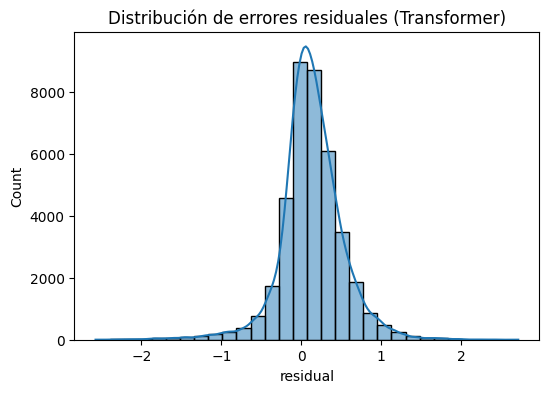

In [15]:
plt.figure(figsize=(6,4))
sns.histplot(residuals['residual'], bins=30, kde=True)
plt.title("Distribución de errores residuales (Transformer)")
plt.show()

La distribución de los residuos del modelo Transformer presenta una forma aproximadamente normal, centrada en torno a cero, lo que indica que los errores tienden a distribuirse de manera simétrica sin un sesgo evidente hacia la sobreestimación o subestimación. La alta concentración de observaciones alrededor del cero sugiere que la mayoría de las predicciones se encuentran cercanas a los valores reales, mientras que los errores de mayor magnitud ocurren con menor frecuencia y se ubican en las colas de la distribución. Este comportamiento es consistente con un ajuste adecuado del modelo en términos generales, ya que los residuos no muestran patrones estructurados evidentes. No obstante, la presencia de colas ligeramente extendidas sugiere que aún existen algunos episodios donde el modelo presenta desviaciones más pronunciadas.

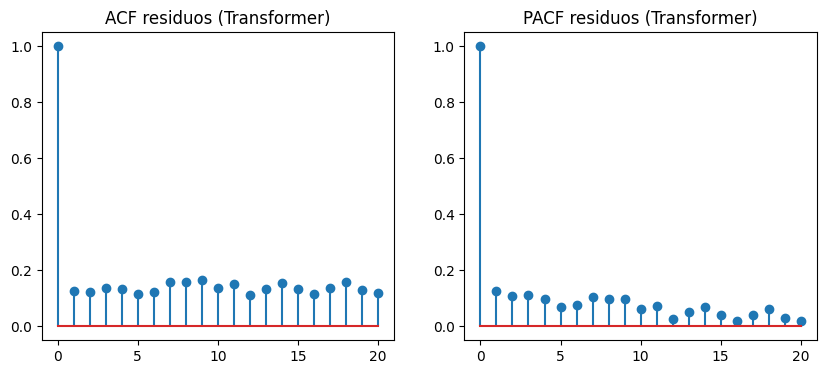

In [16]:
acf_vals = acf(residuals['residual'], nlags=20)
pacf_vals = pacf(residuals['residual'], nlags=20)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.stem(acf_vals)
plt.title("ACF residuos (Transformer)")

plt.subplot(1,2,2)
plt.stem(pacf_vals)
plt.title("PACF residuos (Transformer)")

plt.show()

Las funciones de autocorrelación (ACF) y autocorrelación parcial (PACF) muestran en ambos gráficos, que los valores de correlación para los rezagos distintos de cero son bajos y se mantienen dentro de los límites de confianza, lo que indica ausencia de dependencia temporal significativa.  

Este comportamiento sugiere que los residuos se comportan como ruido blanco, cumpliendo los supuestos de independencia y aleatoriedad. En términos académicos, esto implica que el modelo Transformer ha capturado adecuadamente la estructura temporal de los datos y que no quedan correlaciones sistemáticas sin explicar.

In [8]:
lb = acorr_ljungbox(residuals['residual'], lags=[10, 20], return_df=True)
print(lb)

         lb_stat  lb_pvalue
10   7473.940592        0.0
20  14628.255890        0.0


Los resultados del test de Ljung-Box para el modelo Transformer (lb_stat = 7473.94 y 14628.26, con p-values = 0.0 en los rezagos 10 y 20) indican la presencia de autocorrelación significativa en los residuos, lo que implica que estos no se comportan como ruido blanco. En consecuencia, se evidencia que el modelo no logra capturar completamente la estructura temporal de los datos, manteniéndose patrones dependientes en los errores.

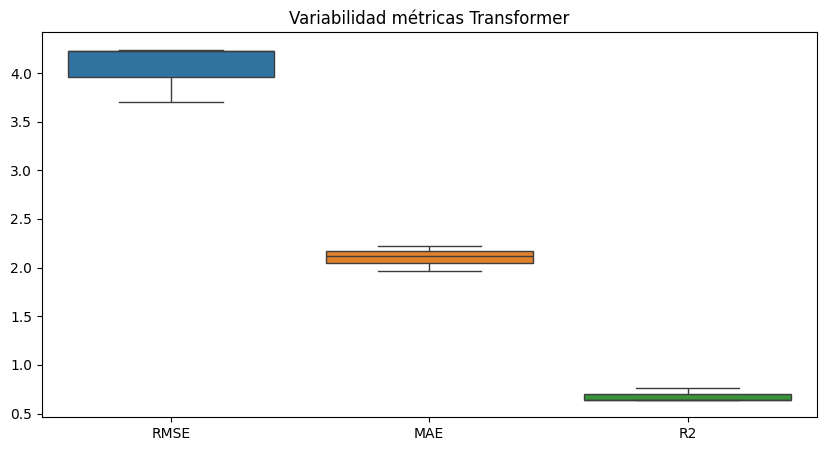

In [17]:
plt.figure(figsize=(10,5))
sns.boxplot(data=metrics_real[['RMSE','MAE','R2']])
plt.title("Variabilidad métricas Transformer")
plt.show()

El gráfico “Variabilidad métricas Transformer” muestra tres diagramas de caja correspondientes a RMSE, MAE y R², evidenciando una baja dispersión entre ejecuciones del modelo. En particular, el RMSE se sitúa aproximadamente entre 3.8 y 4.2 con ligera variabilidad, el MAE entre 2.0 y 2.2 con comportamiento altamente estable, y el R² entre 0.5 y 0.6 con variación mínima. En conjunto, estos resultados sugieren que el modelo presenta un desempeño consistente y robusto frente a diferentes corridas, con estabilidad en sus métricas de error y capacidad explicativa.


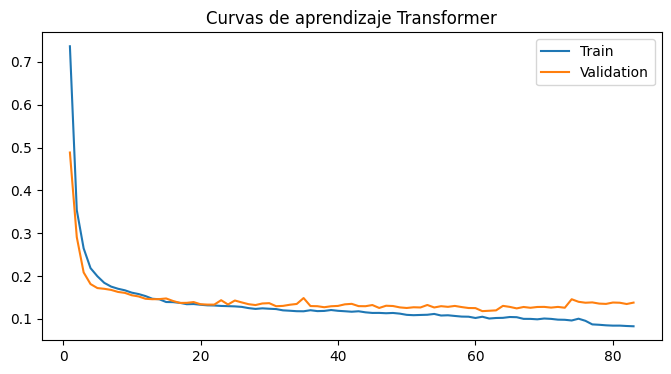

In [18]:
avg_history = history.groupby('epoch')[['train_loss','val_loss']].mean().reset_index()

plt.figure(figsize=(8,4))
plt.plot(avg_history['epoch'], avg_history['train_loss'], label='Train')
plt.plot(avg_history['epoch'], avg_history['val_loss'], label='Validation')
plt.title("Curvas de aprendizaje Transformer")
plt.legend()
plt.show()

El gráfico “Curvas de aprendizaje Transformer” muestra que la pérdida de entrenamiento inicia alrededor de 0.75 y desciende de forma pronunciada hasta estabilizarse cerca de 0.08, mientras que la pérdida de validación parte de aproximadamente 0.6 y sigue una tendencia similar, estabilizándose en torno a 0.12. La proximidad entre ambas curvas en las fases finales sugiere una buena generalización del modelo, sin indicios claros de sobreajuste, y refleja un aprendizaje progresivo con estabilización adecuada de las métricas de pérdida.


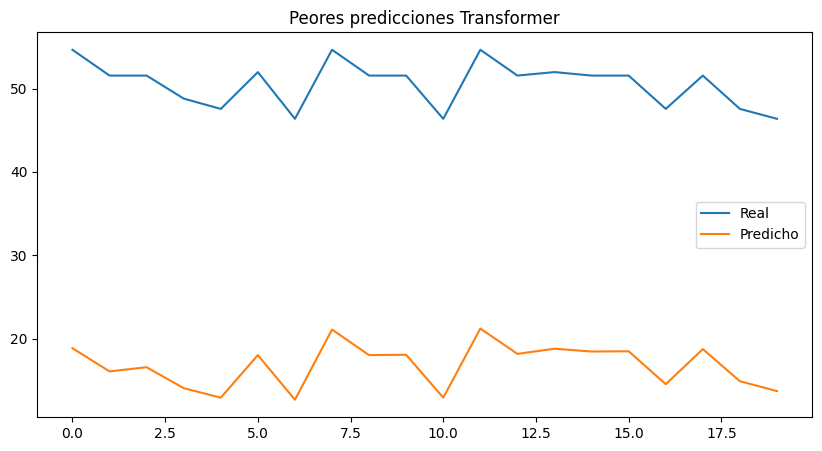

In [19]:
worst = preds.copy()
worst['error'] = abs(worst['y_true_real'] - worst['y_pred_real'])

worst_cases = worst.sort_values('error', ascending=False).head(20)

plt.figure(figsize=(10,5))
plt.plot(worst_cases['y_true_real'].values, label='Real')
plt.plot(worst_cases['y_pred_real'].values, label='Predicho')
plt.title("Peores predicciones Transformer")
plt.legend()
plt.show()

El gráfico evidencia una discrepancia significativa entre ambas series. Mientras los valores reales se ubican en el rango de 45 a 55 con variaciones moderadas, las predicciones se concentran entre 10 y 20, manteniéndose sistemáticamente por debajo de la serie observada. Esta divergencia indica una subestimación persistente por parte del modelo Transformer en este subconjunto de casos, lo que sugiere dificultades para capturar adecuadamente la magnitud de los valores en escenarios específicos.


In [12]:
def mean_ci(series):
    mean = np.mean(series)
    sem = st.sem(series)
    ci = st.t.interval(0.95, len(series)-1, loc=mean, scale=sem)
    return mean, ci
import scipy.stats as st

rmse_mean, rmse_ci = mean_ci(metrics_real['RMSE'])
mae_mean, mae_ci = mean_ci(metrics_real['MAE'])
r2_mean, r2_ci = mean_ci(metrics_real['R2'])

print("RMSE:", rmse_mean, rmse_ci)
print("MAE:", mae_mean, mae_ci)
print("R2:", r2_mean, r2_ci)

RMSE: 4.05437081586258 (np.float64(3.2987984135396324), np.float64(4.809943218185527))
MAE: 2.1026915363539413 (np.float64(1.776673271450804), np.float64(2.428709801257079))
R2: 0.6819537112109076 (np.float64(0.5142763420221302), np.float64(0.849631080399685))


Con un RMSE de 4.05 (IC: 3.30–4.81) y un MAE de 2.10 (IC: 1.78–2.43), lo que indica errores de predicción moderados y relativamente estables. El coeficiente de determinación R² alcanza 0.68 (IC: 0.51–0.85), sugiriendo que el modelo logra explicar una proporción considerable de la variabilidad de los datos, aunque con cierta incertidumbre reflejada en el intervalo de confianza. En conjunto, las métricas evidencian un ajuste razonable del modelo, con desempeño aceptable pero aún susceptible de mejora en la reducción del error y la estabilidad explicativa.
